In [15]:
import os
import glob
import json
import shutil
import cv2
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split

DATASET_DIR = Path("/kaggle/input/datasets/quandang/nomnaocr")
WORKING_DIR = Path("/kaggle/working/yolo_nom_dataset")

if WORKING_DIR.exists():
    shutil.rmtree(WORKING_DIR)

(WORKING_DIR / "images/train").mkdir(parents=True, exist_ok=True)
(WORKING_DIR / "images/val").mkdir(parents=True, exist_ok=True)
(WORKING_DIR / "labels/train").mkdir(parents=True, exist_ok=True)
(WORKING_DIR / "labels/val").mkdir(parents=True, exist_ok=True)

ignore_files = set()
ignores_path = DATASET_DIR / "Ignores"
if ignores_path.exists():
    for f in ignores_path.glob("*"):
        ignore_files.add(f.stem)

page_boxes_map = {}

raw_jsons = list((DATASET_DIR / "Raw").rglob("*.json"))
print(f"Found {len(raw_jsons)} raw JSON metadata files.")

for json_path in raw_jsons:
    try:
        with open(json_path, "r", encoding="utf-8") as f:
            data = json.load(f)
            
        pages_data = data if isinstance(data, list) else [data]
        
        for item in pages_data:
            page_id = item.get("page_id") or item.get("name") or json_path.stem
            lines = item.get("lines", []) or item.get("shapes", []) or item.get("annotations", [])
            
            boxes = []
            for line in lines:
                points = line.get("points") or line.get("box") or line.get("polygon")
                if not points:
                    continue
                
                pts = np.array(points)
                x_min, y_min = pts[:, 0].min(), pts[:, 1].min()
                x_max, y_max = pts[:, 0].max(), pts[:, 1].max()
                
                boxes.append((x_min, y_min, x_max, y_max))
                
            if boxes:
                page_boxes_map[page_id] = boxes
    except Exception as e:
        continue

page_imgs = list((DATASET_DIR / "Pages").rglob("imgs/*.jpg"))
valid_pages = [p for p in page_imgs if p.stem not in ignore_files]

print(f"Found {len(valid_pages)} valid page images.")

train_pages, val_pages = train_test_split(valid_pages, test_size=0.15, random_state=42)

def convert_and_save(page_list, split_type):
    valid_count = 0
    box_count = 0
    
    for page_path in page_list:
        page_name = page_path.stem
        
        img = cv2.imread(str(page_path))
        if img is None:
            continue
        h_img, w_img, _ = img.shape

        boxes = page_boxes_map.get(page_name, [])
        
        label_file = page_path.parent.parent / "Label.txt"
        if not boxes and label_file.exists():
            with open(label_file, "r", encoding="utf-8") as lf:
                for line in lf:
                    parts = line.strip().split("\t")
                    if len(parts) >= 2 and page_name in parts[0]:
                        try:
                            anno = json.loads(parts[1])
                            for shape in anno:
                                pts = np.array(shape["points"])
                                x_min, y_min = pts[:, 0].min(), pts[:, 1].min()
                                x_max, y_max = pts[:, 0].max(), pts[:, 1].max()
                                boxes.append((x_min, y_min, x_max, y_max))
                        except:
                            pass

        yolo_labels = []
        for x_min, y_min, x_max, y_max in boxes:
            x_center = ((x_min + x_max) / 2.0) / w_img
            y_center = ((y_min + y_max) / 2.0) / h_img
            bw = (x_max - x_min) / w_img
            bh = (y_max - y_min) / h_img

            x_center = max(0.0, min(1.0, x_center))
            y_center = max(0.0, min(1.0, y_center))
            bw = max(0.0, min(1.0, bw))
            bh = max(0.0, min(1.0, bh))

            if bw > 0 and bh > 0:
                yolo_labels.append(f"0 {x_center:.6f} {y_center:.6f} {bw:.6f} {bh:.6f}")

        dst_img_path = WORKING_DIR / f"images/{split_type}" / page_path.name
        shutil.copy(page_path, dst_img_path)
        
        dst_label_path = WORKING_DIR / f"labels/{split_type}" / f"{page_name}.txt"
        with open(dst_label_path, "w") as f:
            f.write("\n".join(yolo_labels))
            
        if yolo_labels:
            valid_count += 1
            box_count += len(yolo_labels)

    print(f"[{split_type.upper()}] Processed {valid_count} images with {box_count} total text column boxes.")

convert_and_save(train_pages, "train")
convert_and_save(val_pages, "val")

Found 83 raw JSON metadata files.
Found 2953 valid page images.
[TRAIN] Processed 2510 images with 32835 total text column boxes.
[VAL] Processed 443 images with 5779 total text column boxes.


In [16]:
yaml_content = f"""
path: {WORKING_DIR.absolute()}
train: images/train
val: images/val

names:
  0: text_column
"""

yaml_file_path = WORKING_DIR / "data.yaml"
with open(yaml_file_path, "w") as f:
    f.write(yaml_content.strip())

print(f"Data YAML created at: {yaml_file_path}")

Data YAML created at: /kaggle/working/yolo_nom_dataset/data.yaml


In [17]:
!pip install ultralytics -q

from ultralytics import YOLO

model = YOLO("yolov8s.pt")

results = model.train(
    data=str(WORKING_DIR / "data.yaml"),
    epochs=50,
    imgsz=640,
    batch=16,
    workers=4,
    device=0,
    
    hsv_h=0.05,
    hsv_s=0.8,
    hsv_v=0.6,
    degrees=5.0,
    scale=0.2,
    fliplr=0.0,
    
    project="NomNaOCR_Detection",
    name="yolov8s_nom_column_mobile_ready",
    save=True
)

/usr/lib/python3.12/pty.py:95: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/yolo_nom_dataset/data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.05, hsv_s=0.8, hsv_v=0.6, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8s_nom_column_

/usr/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 523.4±142.1 MB/s, size: 82.7 KB)
val: Scanning /kaggle/working/yolo_nom_dataset/labels/val... 443 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 443/443 736.8it/s 0.6s0.1s
val: New cache created: /kaggle/working/yolo_nom_dataset/labels/val.cache
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.002, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
Plotting labels to /kaggle/working/runs/detect/NomNaOCR_Detection/yolov8s_nom_column_mobile_ready/labels.jpg... 
Image sizes 640 train, 640 val
Using 2 dataloader workers
Logging results to /kaggle/working/runs/detect/NomNaOCR_Detection/yolov8s_nom_column_mobile_ready
Starting training for 50 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       1/50      4.31G      1.452     

/usr/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/usr/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      41/50      4.97G     0.4696     0.2528     0.8246        105        640: 100% ━━━━━━━━━━━━ 157/157 3.7it/s 42.1s0.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 14/14 4.3it/s 3.2s0.2s
                   all        443       5779      0.998      0.999      0.995      0.842

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      42/50      4.97G     0.4593     0.2441     0.8218        113        640: 100% ━━━━━━━━━━━━ 157/157 3.8it/s 41.2s0.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 14/14 4.3it/s 3.3s0.2s
                   all        443       5779      0.998      0.998      0.995      0.864

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      43/50      4.97G      0.457     0.2394     0.8226        133        6

/usr/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


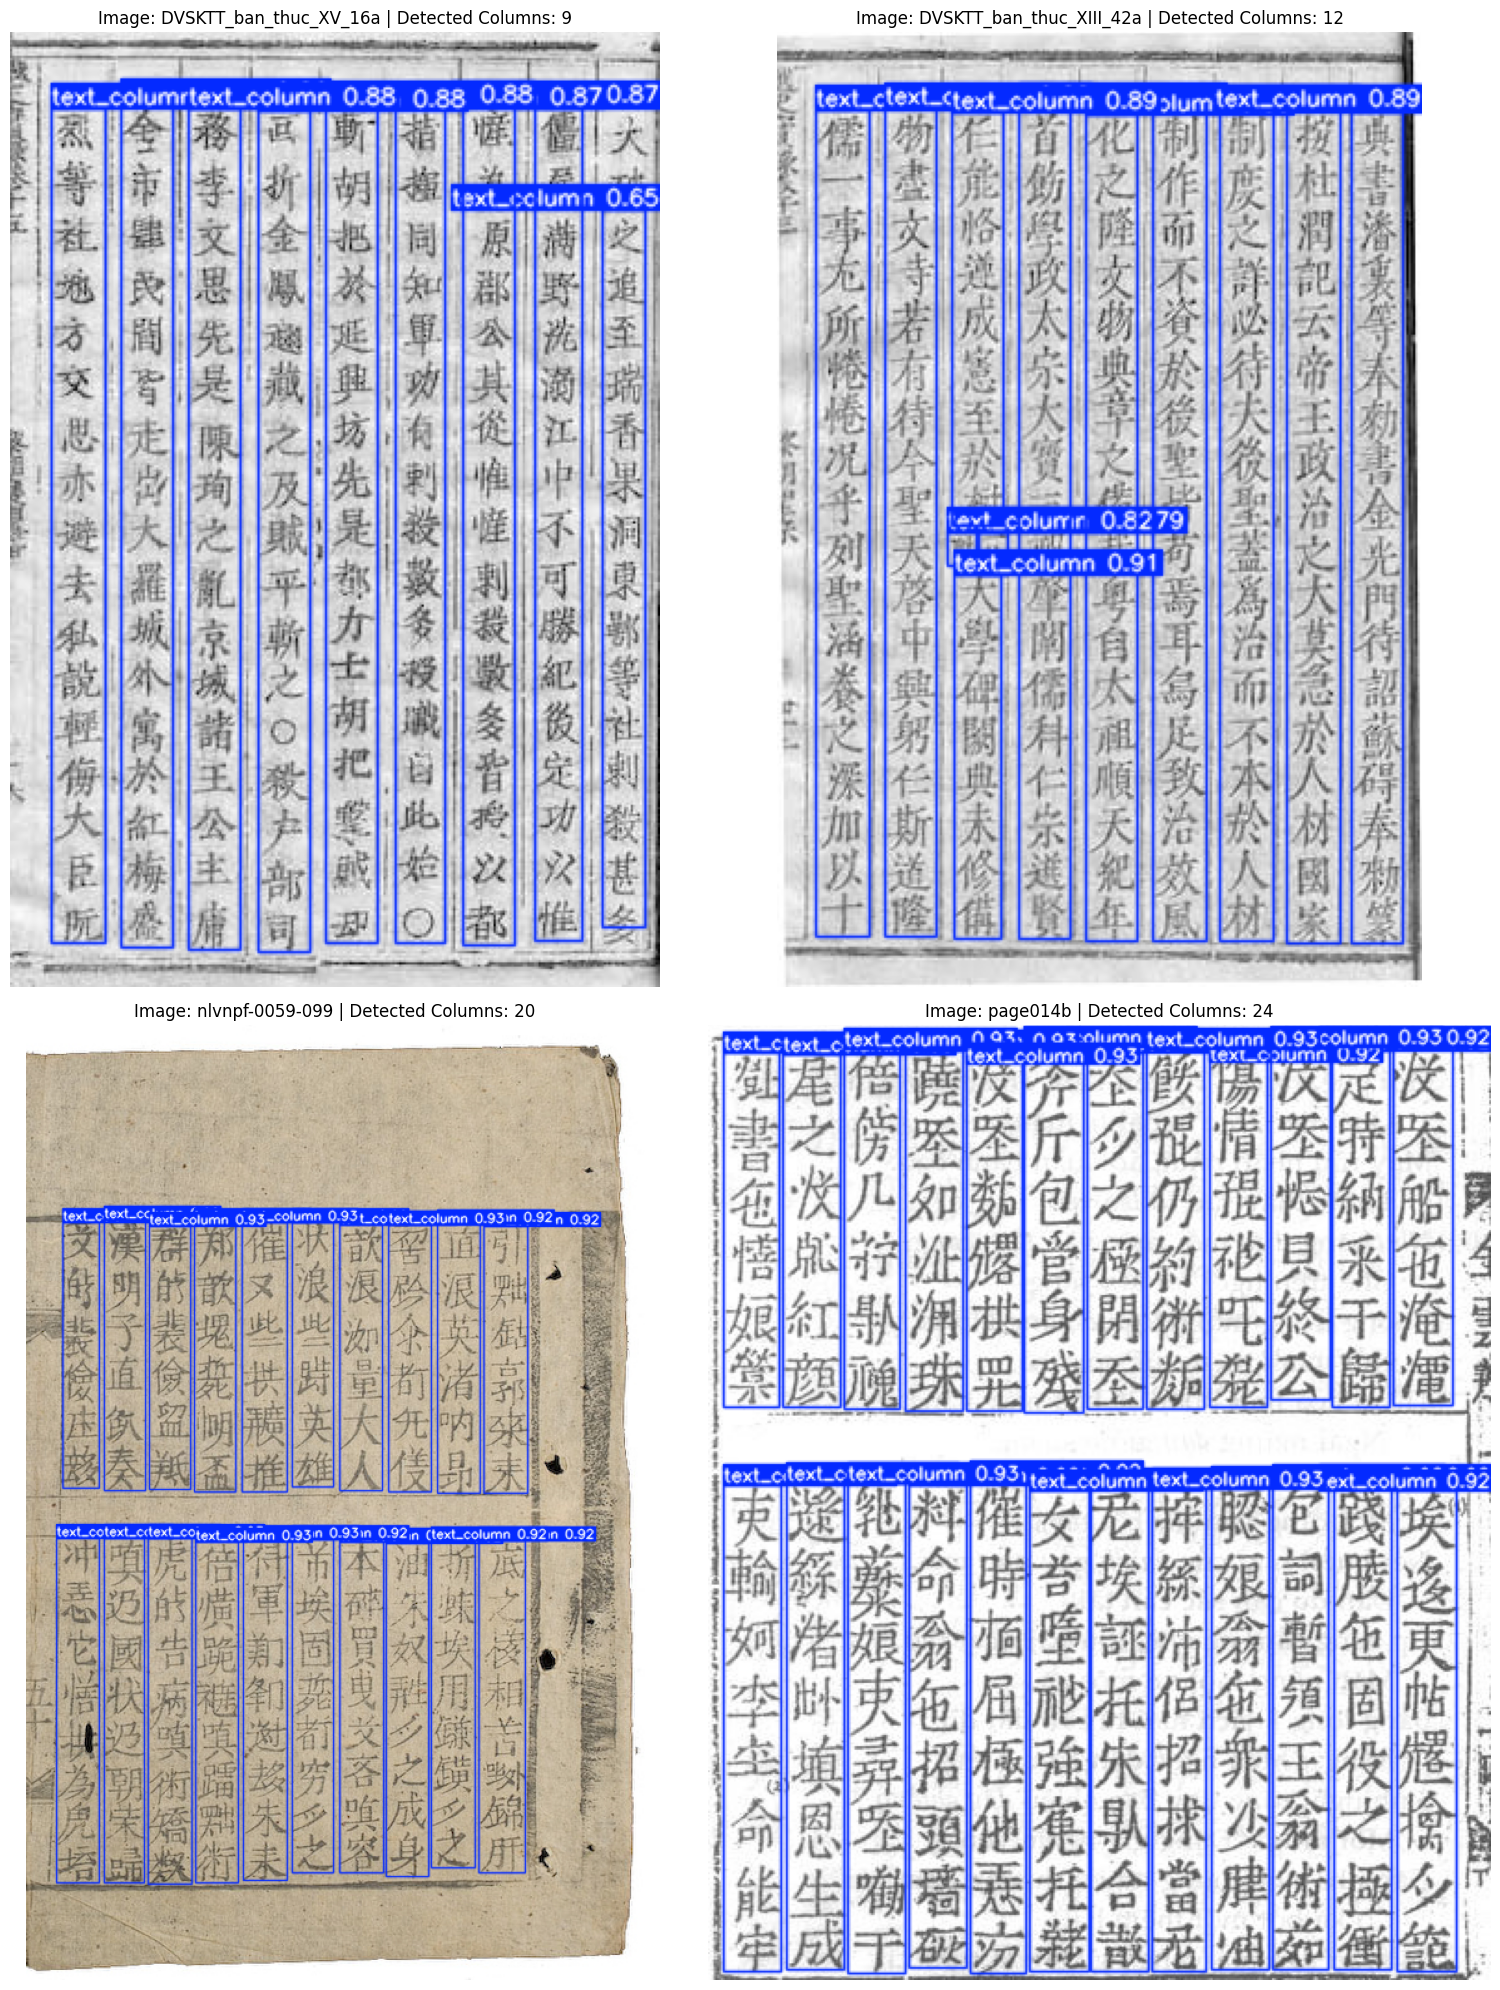

In [18]:
import cv2
import random
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO

# 1. Load the trained model
model_path = "/kaggle/working/runs/detect/NomNaOCR_Detection/yolov8s_nom_column/weights/best.pt"
model = YOLO(model_path)

# 2. Pick 4 random validation images to test
val_images = list(Path("/kaggle/working/yolo_nom_dataset/images/val").glob("*.jpg"))
sample_images = random.sample(val_images, k=min(4, len(val_images)))

# 3. Set up matplotlib figure
fig, axes = plt.subplots(2, 2, figsize=(16, 20))
axes = axes.flatten()

for idx, img_path in enumerate(sample_images):
    # Run model prediction
    # conf=0.25 filters out weak predictions; iou=0.45 handles overlapping boxes
    results = model.predict(source=str(img_path), conf=0.25, iou=0.45, verbose=False)[0]

    # Render bounding boxes onto the original image (OpenCV BGR format)
    annotated_frame = results.plot(line_width=1, font_size=10)
    
    # Convert BGR to RGB for correct display in Matplotlib
    annotated_rgb = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)

    # Plot image
    axes[idx].imshow(annotated_rgb)
    axes[idx].set_title(f"Image: {img_path.stem} | Detected Columns: {len(results.boxes)}", fontsize=12)
    axes[idx].axis("off")

plt.tight_layout()
plt.show()

In [21]:
from ultralytics import YOLO

# 1. Load your best trained PyTorch model
best_model_path = "/kaggle/working/runs/detect/NomNaOCR_Detection/yolov8s_nom_column/weights/best.pt"
model = YOLO(best_model_path)

# 2. Export to LiteRT (TFLite) with INT8 Quantization (Recommended for Mobile)
model.export(format="litert", quantize=8)

print("TFLite / LiteRT export complete! Your .tflite model is ready for Android integration.")

Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
WARNING ⚠️ LiteRT INT8 export does not support end2end models, disabling end2end branch.
WARNING ⚠️ INT8 export requires a missing 'data' arg for calibration. Using default 'data=coco8.yaml'.
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs

PyTorch: starting from '/kaggle/working/runs/detect/NomNaOCR_Detection/yolov8s_nom_column/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (21.5 MB)
LiteRT: collecting INT8 calibration images from 'data=coco8.yaml'
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 872.7±280.2 MB/s, size: 54.0 KB)
val: Scanning /kaggle/working/datasets/coco8/labels/val.cache... 4 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4/4 1.1Mit/s 0.0s
WARNING ⚠️ LiteRT: >300 images recommended for INT8 calibration, found 4 images.

LiteRT: starting export with litert_torch 0.9.3...


(00:00) [START] LiteRT-Torch Convert

(00:00) [START] LiteRT-Torch Convert > Torch Export: serving_default

(00:00) [START] LiteRT-Torch Convert > Torch Export: serving_default > ExportedProgram Run Decompositions

/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


...

(00:00) [START] Write Model to 
/kaggle/working/runs/detect/NomNaOCR_Detection/yolov8s_nom_column/weights/best_int8.tflite

(00:00) [ DONE] Write Model to 
/kaggle/working/runs/detect/NomNaOCR_Detection/yolov8s_nom_column/weights/best_int8.tflite (+00:00)

LiteRT: applying static quantization (int8 weights + int8 activations)...


/usr/local/lib/python3.12/dist-packages/ai_edge_litert/interpreter.py:480: UserWarning: Warning: Enabling `experimental_preserve_all_tensors` with the BUILTIN or AUTO op resolver is intended for debugging purposes only. Be aware that this can significantly increase memory usage by storing all intermediate tensors. If you encounter memory problems or are not actively debugging, consider disabling this option.
  warnings.warn(
Applying Transformations to tensors:: 100%|██████████| 410/410 [00:00<00:00, 25046.09it/s]


Model name: /kaggle/working/runs/detect/NomNaOCR_Detection/yolov8s_nom_column/weights/best_int8.tflite
Original model size: 42.66 MiB
Quantized model size: 11.04 MiB
Quantization Ratio: 0.26 (3.9x smaller)
Total time: 211.57 ms
LiteRT: export success ✅ 19.7s, saved as '/kaggle/working/runs/detect/NomNaOCR_Detection/yolov8s_nom_column/weights/best_int8.tflite' (11.0 MB)

Export complete (20.3s)
Results saved to /kaggle/working/runs/detect/NomNaOCR_Detection/yolov8s_nom_column/weights/best_int8.tflite
Predict:         yolo predict task=detect model=/kaggle/working/runs/detect/NomNaOCR_Detection/yolov8s_nom_column/weights/best_int8.tflite imgsz=640 
Validate:        yolo val task=detect model=/kaggle/working/runs/detect/NomNaOCR_Detection/yolov8s_nom_column/weights/best_int8.tflite imgsz=640 data=/kaggle/working/yolo_nom_dataset/data.yaml  
Visualize:       https://netron.app
TFLite / LiteRT export complete! Your .tflite model is ready for Android integration.
